<a href="https://drive.google.com/file/d/1b7tSyJBpWggHEBGdWa80JdKh7VNq2FEf/view?usp=sharing" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Problem 1
Implement serial test and apply to a `samples`

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def rng(m=2**32, a=1103515245, c=12345):
    rng.current = (a * rng.current + c) % m
    return rng.current / m

rng.current = 1

samples = [rng() for _ in range(1000)]

In [4]:
if len(samples) % 2 != 0:
    samples = samples[:-1]  # Удаляем последний элемент, если нечётное количество

points = np.array([(samples[i], samples[i+1]) for i in range(0, len(samples), 2)])
x, y = points[:, 0], points[:, 1]

k = 20
f_obs= np.histogram2d(x, y, bins=[k, k])[0]
per_bin = len(points) / (k * k)
f_exp = np.full((k, k), per_bin)

chi2, p_value = stats.chisquare(f_obs.flatten(), f_exp.flatten())
print(f"Chi2: {chi2}, p-value: {p_value}")

Chi2: 386.40000000000003, p-value: 0.6653662117152015


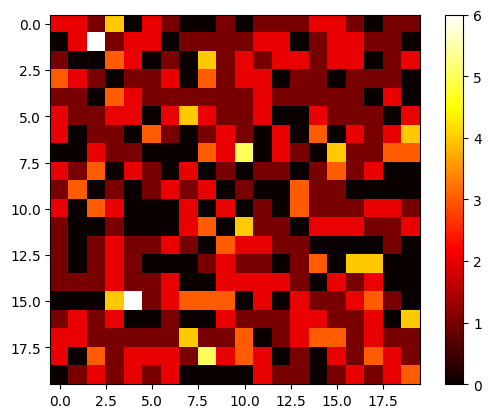

In [5]:
plt.imshow(f_obs, cmap='hot', interpolation='nearest')
plt.colorbar()
plt.show()

### Problem 2*
Implement permutation test and apply to a `samples`

In [6]:
from itertools import permutations

d = 3  
n = len(samples) - len(samples) % d  # Обрезаем до длины, кратной d
samples = samples[:n]  

groups = [samples[i:i+d] for i in range(0, n - d + 1, d)]

# Все возможные перестановки для d элементов
perm_list = list(permutations(range(d)))
num_permutations = len(perm_list)
perm_count = {perm: 0 for perm in perm_list}

for group in groups:
    ranking = tuple(np.argsort(group))
    perm_count[ranking] += 1

expected_freq = len(groups) / num_permutations

chi_square_stat = sum((count - expected_freq)**2 / expected_freq 
                     for count in perm_count.values())

p_value = 1 - stats.chi2.cdf(chi_square_stat, df=num_permutations - 1)

print(f"Total groups: {len(groups)}")
print(f"Possible permutations: {num_permutations}")
print(f"Chi-square statistic: {chi_square_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject H0: The sequence is not uniformly random.")
else:
    print("Fail to reject H0: The sequence appears uniformly random.")

Total groups: 333
Possible permutations: 6
Chi-square statistic: 4.8559
P-value: 0.4337
Fail to reject H0: The sequence appears uniformly random.


### Problem 3

Provide a statistical test to show that `rng_bad` has problems but `rng_good` does not.

In [7]:
from scipy.stats import chisquare

# Плохой генератор 
def rng_bad(m=2**31, a=65539, c=0):
    rng_bad.current = (a * rng_bad.current + c) % m
    return rng_bad.current / m
rng_bad.current = 1

# Обычный LCG генератор
def rng(m=2**32, a=1103515245, c=12345):
    rng.current = (a * rng.current + c) % m
    return rng.current / m
rng.current = 1

N = 50001  
bad_samples = [rng_bad() for _ in range(N)]
good_samples = [rng() for _ in range(N)]

def serial_test_3d(sample, grid=20):

    trunc_len = len(sample) - len(sample) % 3
    points = np.array(sample[:trunc_len]).reshape(-1, 3)
    f_obs, _ = np.histogramdd(points, bins=[grid, grid, grid])
    f_exp = np.full((grid, grid, grid), len(points) / (grid**3))
    statistic, pvalue = chisquare(f_obs.flatten(), f_exp.flatten())
    return statistic, pvalue

stat_bad_3d, p_bad_3d = serial_test_3d(bad_samples)
stat_good_3d, p_good_3d = serial_test_3d(good_samples)

print("Результаты 3D серийного теста:")
print(f"rng_bad: Chi2 = {stat_bad_3d:.1f}, p-value = {p_bad_3d:.3g}")
print(f"rng:     Chi2 = {stat_good_3d:.1f}, p-value = {p_good_3d:.3g}")


Результаты 3D серийного теста:
rng_bad: Chi2 = 20051.8, p-value = 0
rng:     Chi2 = 8043.4, p-value = 0.361


### Problem 4
Simulate a sample of 1000 from a discrete distribution on a set of digits $0, 1, 2, \ldots, 9$ with weights $0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2$. Construct a histogram from the sample. Optimise the algorithm by ordering the weights.

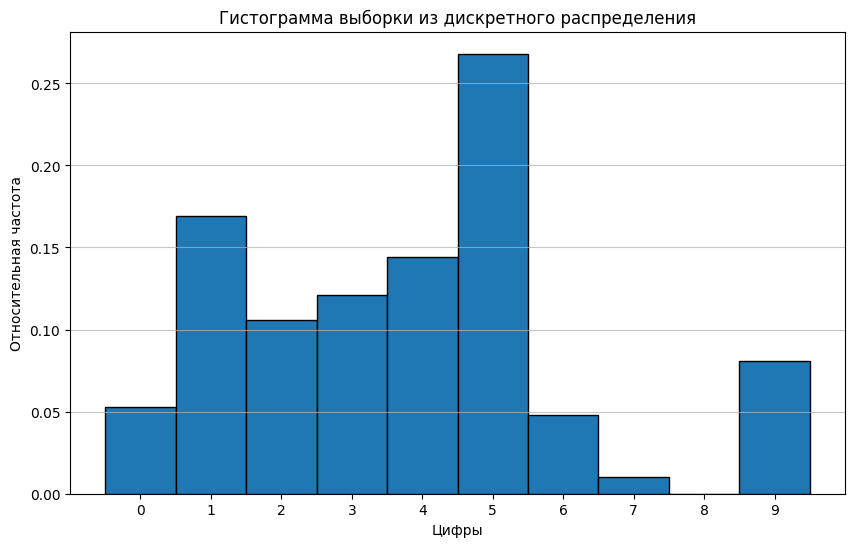

In [8]:
def generate_discrete_sample(weights, size=1000):
    
    digits = np.arange(10)
    sorted_indices = np.argsort(weights)[::-1]
    sorted_weights = np.array(weights)[sorted_indices]
    sorted_digits = digits[sorted_indices]
    
    norm_weights = sorted_weights / np.sum(sorted_weights)
    
    sample = np.random.choice(sorted_digits, size=size, p=norm_weights)
    
    return sample

weights = [0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2]

sample = generate_discrete_sample(weights, 1000)

plt.figure(figsize=(10, 6))
plt.hist(sample, bins=np.arange(11)-0.5, edgecolor='black', density=True)
plt.xticks(range(10))
plt.xlabel('Цифры')
plt.ylabel('Относительная частота')
plt.title('Гистограмма выборки из дискретного распределения')
plt.grid(axis='y', alpha=0.75)
plt.show()



### Problem 5
Simulate a sample of size 1000 from the distribution $\operatorname{Exp}(\lambda)$ using the Inverse transform method. Construct a sample histogram and an accurate plot of the distribution density.

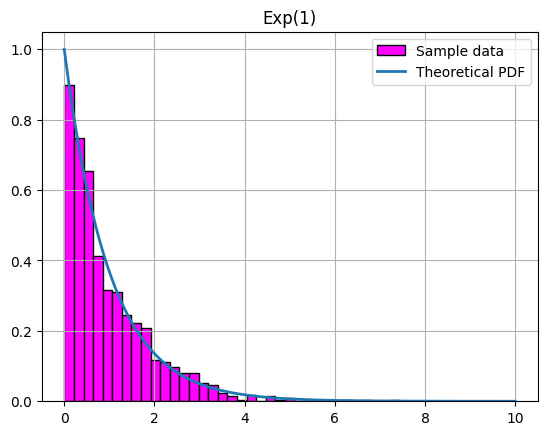

In [9]:
lambda_ = 1
n = 1000
y = np.random.rand(n)
x = -np.log(1 - y) / lambda_

x_theory = np.linspace(0, 10, 1000)
y_theory = lambda_ * np.exp(-lambda_*x_theory)

plt.hist(x, bins=35, density=True, edgecolor = 'black', color = 'magenta', label='Sample data')
plt.plot(x_theory, y_theory, lw=2, label='Theoretical PDF')
plt.title(f'Exp({lambda_})')
plt.legend()
plt.grid(True)
plt.show()

### Problem 6
Justify (orally) that the accept-reject method really samples from the required distribution. Simulate $1000$ points from the distribution with density $e^xcos^2x \cdot \mathbb{I}_{[-\frac\pi2, \frac\pi2]}$. Plot the sampled histogram on the sample and compare it with the plot of the exact density function.

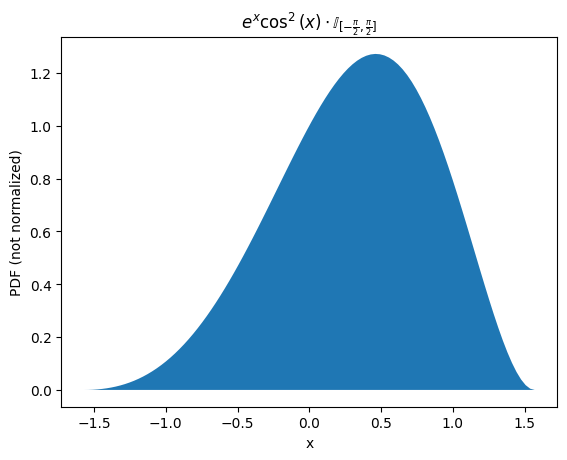

In [10]:
fig = plt.figure()

x = np.linspace(-np.pi/2, np.pi/2, 100)
density = np.exp(x) * np.cos(x) ** 2 # not normalized density!
plt.fill_between(x, 0, density)
plt.ylabel('PDF (not normalized)')
plt.xlabel('x')
plt.title(r'$e^x \cos^2(x) \cdot \mathbb{I}_{[-\frac{\pi}{2}, \frac{\pi}{2}]}$')

plt.show()

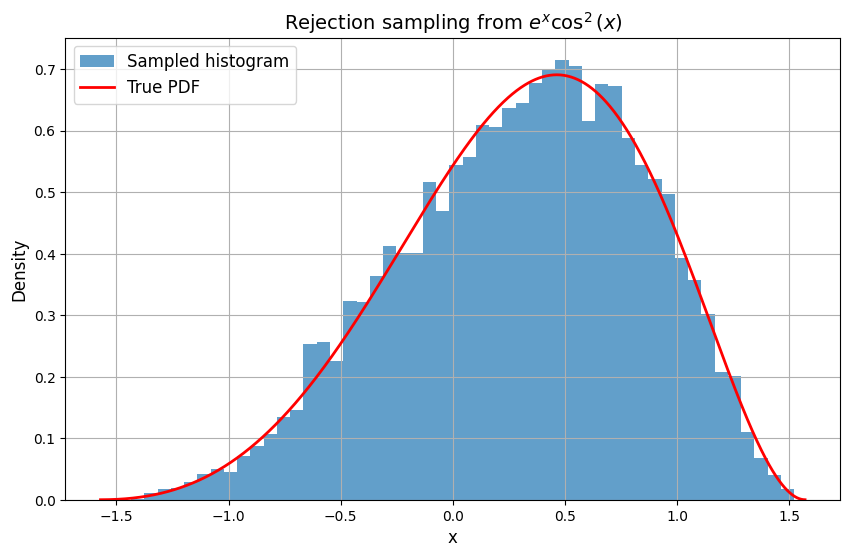

In [11]:
def pi(x):
    return np.exp(x) * np.cos(x)**2

def p(x):
    return 1 / np.pi

x_val = np.linspace(-np.pi/2, np.pi/2, 1000)
M = np.max(pi(x_val)) / p(x_val[0])  

n = 10000 
points_x = []
points_y = []

# Генерация методом "принять-отклонить"
while len(points_x) < n:
    x = np.random.uniform(-np.pi/2, np.pi/2)  
    y = np.random.uniform(0, M * p(x))        
    if y <= pi(x):                            
        points_x.append(x)
        points_y.append(y)

points_x = np.array(points_x)
points_y = np.array(points_y)

plt.figure(figsize=(10, 6))
plt.hist(points_x, bins=50, density=True, alpha=0.7, label='Sampled histogram')

# Истинная плотность (нормированная)
norm_const = np.trapezoid(pi(x_val), x_val)
true_density = pi(x_val) / norm_const
plt.plot(x_val, true_density, 'r-', linewidth=2, label='True PDF')

plt.title(r'Rejection sampling from $e^x\cos^2(x)$', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

### Problem 7
Model and depict a sample of 500 points uniformly distributed within a given triangle without using a selection method.

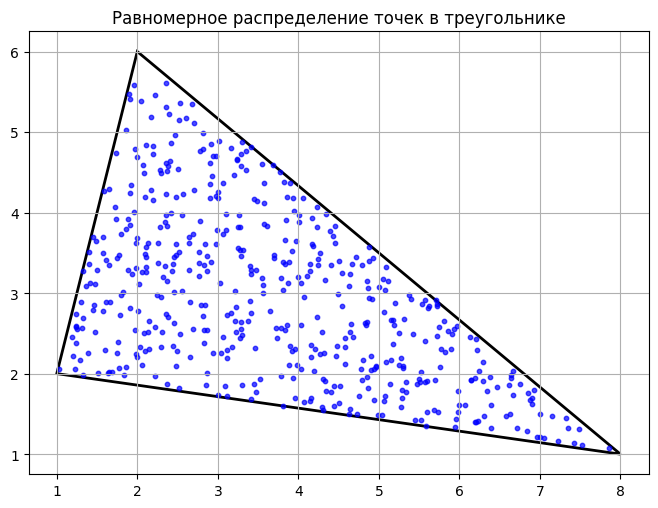

In [14]:
from matplotlib.patches import Polygon

vertices = np.array([[1, 2], [2, 6], [8, 1]])
A, B, C = vertices

# Функция преобразования координат
def transform_to_triangle(u, v):
    
    sqrt_v = np.sqrt(v)
    x = (1 - sqrt_v) * A[0] + sqrt_v * (1 - u) * B[0] + sqrt_v * u * C[0]
    y = (1 - sqrt_v) * A[1] + sqrt_v * (1 - u) * B[1] + sqrt_v * u * C[1]
    return x, y

n_points = 500
u = np.random.rand(n_points)
v = np.random.rand(n_points)

x, y = transform_to_triangle(u, v)

fig, ax = plt.subplots(figsize=(8, 6))
triangle = Polygon(vertices, closed=True, fill=False, edgecolor='black', linewidth=2)
ax.add_patch(triangle)
ax.scatter(x, y, color='blue', s=10, alpha=0.7)
ax.set_aspect('equal')
ax.set_title('Равномерное распределение точек в треугольнике', fontsize=12)
ax.grid(True)
plt.show()

### Problem 8
Model without using the selection method a sample of $500$ points uniformly distributed inside the unit circle. Picture the obtained points. Do they really fill the circle uniformly?

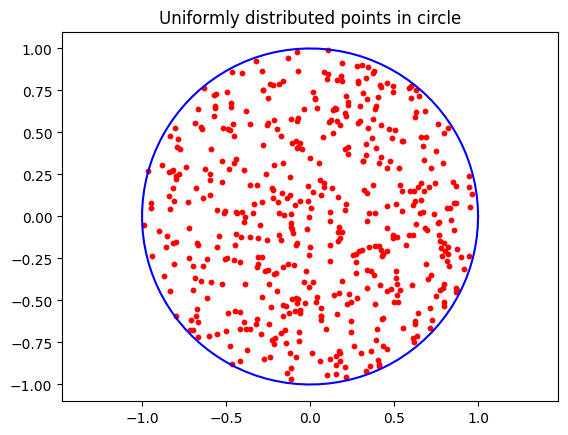

In [15]:
n = 500

r = np.sqrt(np.random.uniform(0, 1, n))
theta = np.random.uniform(0, 2 * np.pi, n)

x = r * np.cos(theta)
y = r * np.sin(theta)

t = np.linspace(0, 2 * np.pi, 100)
plt.plot(np.cos(t), np.sin(t), 'b-')

plt.scatter(x, y, color='r', s=10)

plt.title("Uniformly distributed points in circle")
plt.axis('equal')
plt.show()

# Random normal generator

### Problem 9
Prove (orally) that the following algorithm (**Box-Muller algorithm**, https://en.wikipedia.org/wiki/Box%E2%80%93Muller_transform) generates a sample of independent $\mathcal{N}(0,1)$ random variables. Modify the method to exclude calls of trigonometric functions `np.sin` and `np.cos`. Using the modified method, simulate a sample size of $1000$ from a $2D$ Gaussian distribution with mean $\mu$ and covariance matrix $\Sigma$, where
$$\mu = \begin{pmatrix} 4 \\ 7 \end{pmatrix}^T, \quad \Sigma = \begin{pmatrix} 20 & -4 \\ -4 & 40 \end{pmatrix}.$$
Construct a 2D histogram of the resulting distribution. Compare the sample mean and covariance matrix with the exact values.

In [16]:
import seaborn as sns

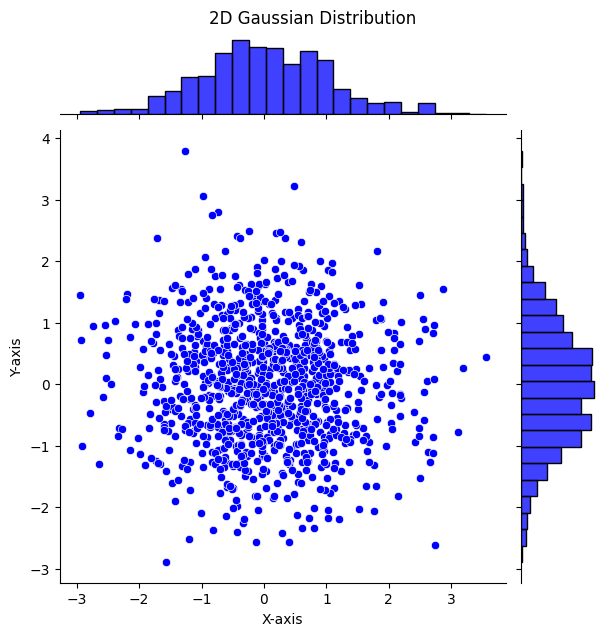

In [17]:
n = 1000
u1, u2 = np.random.rand(2, n)
r = np.sqrt(-2 * np.log(u1))
theta = 2 * np.pi * u2
x = r * np.cos(theta)
y = r * np.sin(theta)


joint_plot = sns.jointplot(x=x, y=y, color="blue")
joint_plot.set_axis_labels('X-axis', 'Y-axis')
plt.suptitle('2D Gaussian Distribution', y=1.02)
plt.show()

[3.99703144 6.99012274] [[21.35861139 -7.29724428]
 [-7.29724428 38.67647725]]


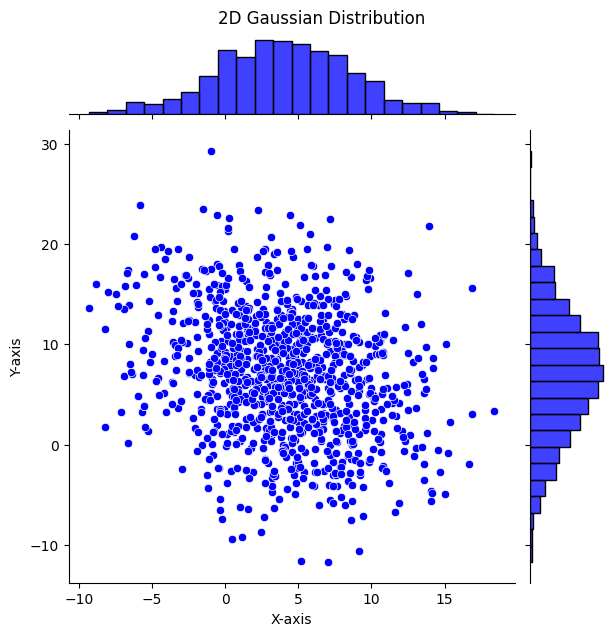

In [18]:
from scipy.linalg import cholesky

n = 1000
Z = np.zeros((n, 2))
i = 0

while i < n:
  u1, u2 = np.random.uniform(-1, 1, 2)
  s = u1**2 + u2**2
  if s < 1:
    Z[i, 0] = u1 * np.sqrt(-2 * np.log(s) / s)
    Z[i, 1] = u2 * np.sqrt(-2 * np.log(s) / s)
    i += 1

mu = np.array([4, 7])
sigma = np.array([[20, -4], [-4, 40]])

L = cholesky(sigma)
X = mu + Z @ L.T
sample_mean = np.mean(X, axis=0)
sample_cov = np.cov(X, rowvar=False)

print(sample_mean, sample_cov)

x = X[:, 0]
y = X[:, 1]
joint_plot = sns.jointplot(x=x, y=y, color="blue")
joint_plot.set_axis_labels('X-axis', 'Y-axis')
plt.suptitle('2D Gaussian Distribution', y=1.02)
plt.show()
